<a href="https://colab.research.google.com/github/Chelladuraimct/ColabFiles/blob/main/eda_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
**EDA Assignment – Retail Sales Dataset**

----

**Step 1: Generate Dataset**

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)

data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)

print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


---
**Task 1 — Inspect & Handle Missing Values**

---

**1. Shape of DataFrame**

In [2]:
print("Shape of DataFrame:", df.shape)

Shape of DataFrame: (200, 6)


**2. Data Types**

In [3]:
print("\nData Types:\n")
print(df.dtypes)


Data Types:

order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object


**3. Missing Values Count**

In [4]:
print("\nMissing Values Count:\n")
print(df.isnull().sum())


Missing Values Count:

order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64


**4. Missing Percentage**

In [5]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage (%):\n")
print(missing_percentage.round(2))


Missing Percentage (%):

order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


---
**Task 2 — Summarize & Visualize**

---

**1. Summary Statistics**

In [6]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


**Observations:**

The order_value column has a very high maximum value compared to the 75th percentile, indicating the presence of extreme outliers (95000, 87000).

The delivery_days column has a relatively small range, showing most deliveries happen within a consistent timeframe.

**2. Histogram for order_value**

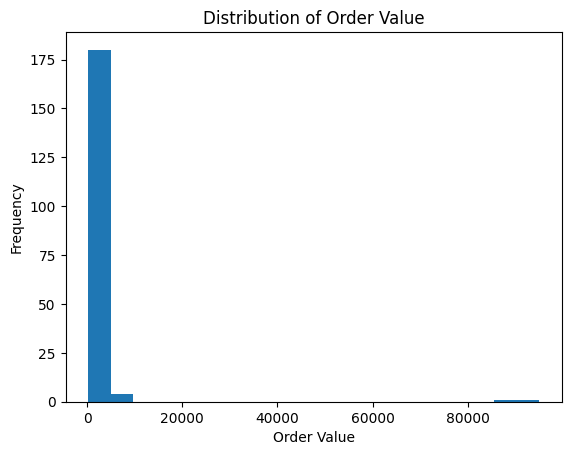

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.hist(df["order_value"].dropna(), bins=20)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

**3. Box Plot for delivery_days**

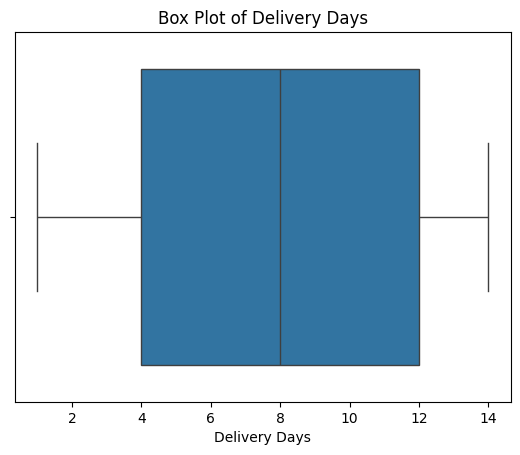

In [8]:
plt.figure()
sns.boxplot(x=df["delivery_days"])
plt.title("Box Plot of Delivery Days")
plt.xlabel("Delivery Days")
plt.show()

---
**Task 3 — Correlation Analysis**

---

**1. Correlation Matrix**


In [9]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


**2. Heatmap**

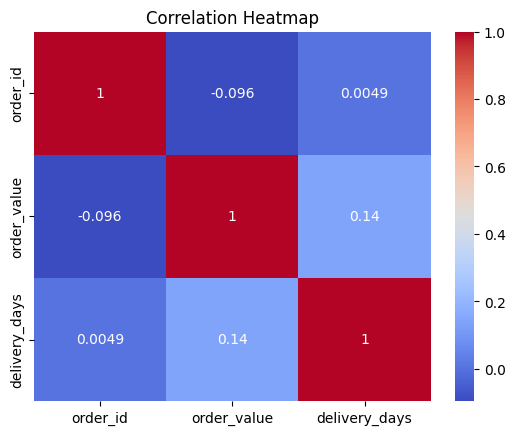

In [10]:
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:**

The correlation between order_value and delivery_days is very weak (close to 0), indicating no strong relationship between order size and delivery time.